# Monte Carlo Value Estimation in Gridworld
This notebook demonstrates how to estimate state values in a Gridworld environment using the Monte Carlo method. The agent explores the environment, collects rewards, and updates the value of each state based on the returns observed from complete episodes. The notebook visualizes the reward structure, the learning process, and the resulting value function.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

## Environment and Parameters Setup
We define the reward structure for each state in the 4x4 grid, set the terminal state, initialize the state values, learning rate (alpha), and a log for scores.

In [2]:
rewards = np.zeros(16)
rewards[3] = 1
rewards[2] = 0
rewards[11] = 0
rewards[10] = 0

terminal_state = 3
state_values = np.zeros(16)
alpha = 0.005
score_log = []

## Visualizing the Reward Structure
This cell visualizes the reward values for each state in the 4x4 grid. High and low reward states are easily identified in the plot.

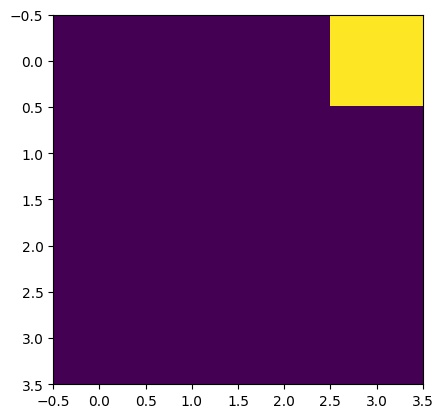

In [3]:
plt.imshow(rewards.reshape(4,4))

## Loading the State Transition Table
We load the state transition table from a CSV file. This table defines how the agent moves between states given an action.

In [4]:
state_transition_table = np.genfromtxt("state_transitions.csv", delimiter=",").astype(int)

## Monte Carlo Update Function
This function implements the Monte Carlo update rule, which updates the value estimates for each state based on the returns observed from complete episodes.

In [5]:
def monte_carlo_update(values, rewards, states):
    returns = []
    R = 0
    gamma = 0.9
    for i in reversed(range(len(rewards))):
        R = rewards[i] + gamma * R
        returns.insert(0, R)

    values[states] = values[states] + alpha*(returns - values[states])
    return values

## Agent Evaluation Function
This function simulates the agent's behavior using the current value estimates to select actions, and returns the total reward and the sequence of visited states.

In [6]:
def test_agent():
    state = 12
    steps = 0
    total_rewards = 0
    states_log = []
    while (not(state == terminal_state)) and steps<30:
        states_log.append(state)
        action = np.argmax(state_values[state_transition_table[state]])
        state = state_transition_table[state, action]
        total_rewards += rewards[state]
        steps += 1
    states_log.append(state)
    return total_rewards, states_log

## Monte Carlo Learning: Main Training Loop
This loop runs multiple episodes where the agent explores the environment, collects rewards, and updates the value estimates for each state using the Monte Carlo update rule. The agent's performance is logged for analysis.

In [7]:
for _ in range(10000):
    state = 12
    state_log = []
    reward_log = []
    steps = 0
    
    while (not(state == terminal_state)) and steps<30:
        reward_log.append(rewards[state])
        state_log.append(state)
        
        action = random.randint(0,3)
        state = state_transition_table[state, action]
        steps += 1
        
    reward_log.append(rewards[state])
    state_log.append(state)
    state_values = monte_carlo_update(state_values, reward_log, state_log)
    
    score_log.append(test_agent()[0])

## Visualizing Learned State Values
This cell displays the learned value for each state after training, helping you see which states are considered more valuable by the agent.

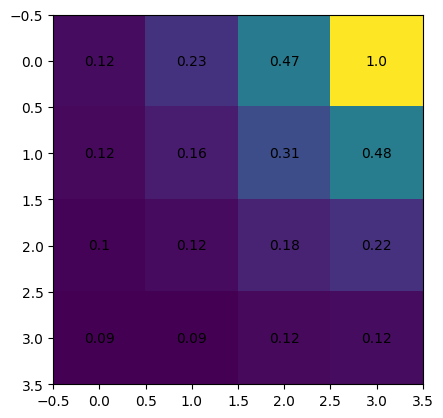

In [8]:
fig1, ax1= plt.subplots(1)
ax1.imshow(state_values.reshape(4, 4))

for (j,i), label in np.ndenumerate(state_values.reshape(4, 4).round(2)):
    ax1.text(i,j,label,ha='center',va='center')

## Plotting the Learning Curve
This cell plots the agent's score over time, showing how the agent's performance improves as it learns.

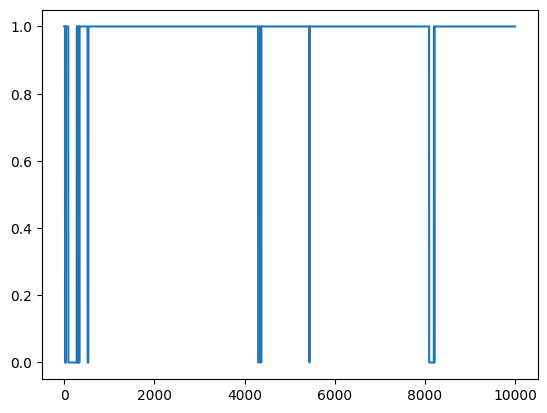

In [9]:
plt.plot(score_log)

## Visualizing the Agent's Path
This cell shows the path taken by the agent from the start state to the terminal state using the learned value function.

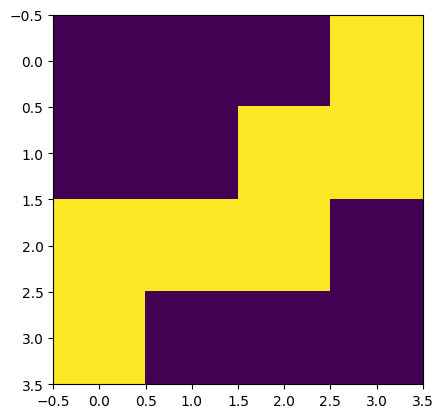

In [10]:
_, state_log = test_agent()
state_view = np.zeros(16)
state_view[state_log] = 1
plt.imshow(state_view.reshape(4,4))